In [1]:
import pandas as pd
import matplotlib.pyplot as plt     
import numpy as np
import seaborn as sns   

df_origin = pd.read_csv('UsedCarsSA_Unclean_EN.csv')
df = df_origin.copy()

In [2]:
df.sample(5)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
327,Changan,Seven,2020,Saudi,Red,Standard,1.5,Gas,Automatic,Used,47528,Riyadh,28500,False
1646,Toyota,Innova,2015,Gulf Arabic,White,Standard,2.7,Gas,Automatic,Used,749000,Riyadh,46000,False
1517,Hyundai,Sonata,2013,Saudi,White,Semi Full,NaN,Gas,Automatic,Used,344506,Jeddah,30000,False
5968,Mercedes,C,2015,Gulf Arabic,Black,Semi Full,NaN,Gas,Automatic,Used,85000,Qassim,119000,False
5698,Hyundai,Elantra,2017,Other,Silver,Standard,NaN,Diesel,Automatic,Used,100000,Riyadh,Negotiable,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8248 non-null   object 
 1   Type         8248 non-null   object 
 2   Year         8248 non-null   int64  
 3   Origin       8153 non-null   object 
 4   Color        8248 non-null   object 
 5   Options      8139 non-null   object 
 6   Engine_Size  5982 non-null   float64
 7   Fuel_Type    8248 non-null   object 
 8   Gear_Type    8174 non-null   object 
 9   Condition    8248 non-null   object 
 10  Mileage      8248 non-null   int64  
 11  Region       8248 non-null   object 
 12  Price        8248 non-null   object 
 13  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(10)
memory usage: 845.9+ KB


Cleaning

In [4]:
# Origin, Options, Engine_Size and Gear_Type columns have some missing values, we need to handle them 
# Price column has some non-numeric values, we need to clean it

In [5]:
df.duplicated().sum()   

np.int64(69)

In [6]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum() 

Make              0
Type              0
Year              0
Origin           95
Color             0
Options         109
Engine_Size    2254
Fuel_Type         0
Gear_Type        74
Condition         0
Mileage           0
Region            0
Price             0
Negotiable        0
dtype: int64

In [8]:
print(9500/8248)
# so the missing values in Origin column is around 1.15%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Origin'])

1.1517943743937924


In [9]:
print(10900/8248)
# so the missing values in Options column is around 1.32%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Options'])

1.3215324927255092


In [10]:
print(7400/8248)
# so the missing values in Gear_Type column is around 0.74%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Gear_Type'])

0.8971871968962173


In [11]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Engine_Size']
      .transform('mean')
)

In [12]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Make', 'Type', 'Year'])['Engine_Size']
      .transform('mean')
)

In [13]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'].info()

<class 'pandas.core.series.Series'>
Index: 8051 entries, 0 to 8247
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
5546 non-null   float64
dtypes: float64(1)
memory usage: 125.8 KB


In [14]:
df['Price'] = df['Price'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Price']
     .transform('mean'))

In [15]:
df.isna().sum()

Make             0
Type             0
Year             0
Origin           0
Color            0
Options          0
Engine_Size    430
Fuel_Type        0
Gear_Type        0
Condition        0
Mileage          0
Region           0
Price          503
Negotiable       0
dtype: int64

In [16]:
df['Engine_Size'] = df['Engine_Size'].fillna(df['Engine_Size'].mean())

In [17]:
df['Price'] = df['Price'].fillna(df['Price'].mean())

In [18]:
df.isna().sum() 

Make           0
Type           0
Year           0
Origin         0
Color          0
Options        0
Engine_Size    0
Fuel_Type      0
Gear_Type      0
Condition      0
Mileage        0
Region         0
Price          0
Negotiable     0
dtype: int64

In [19]:
df['Car_Age'] = 2024 - df['Year']
df['Car_Age']

0        6
1        8
2        5
3        5
4        5
        ..
8243     9
8244    14
8245    11
8246    13
8247    11
Name: Car_Age, Length: 8051, dtype: int64

<Axes: title={'center': 'Price Distribution'}>

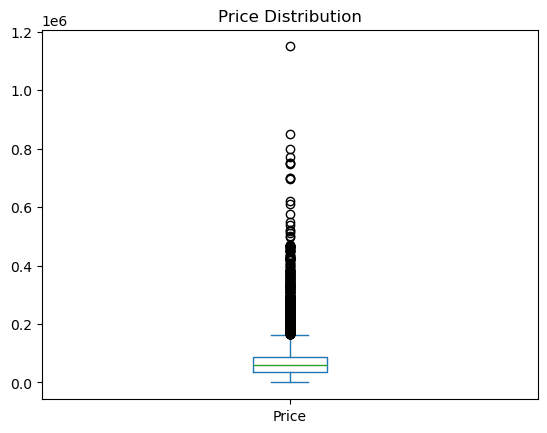

In [20]:
df['Price'].plot(kind='box', title='Price Distribution')

In [21]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f'Number of outliers in Price: {len(outliers)}')

Number of outliers in Price: 633


In [23]:
df[df['Price'] > upper_bound].sample(10)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable,Car_Age
941,Mercedes,A,2021,Other,Black,Standard,4.00,Gas,Automatic,Used,10000,Riyadh,179000.000000,False,3
8052,Toyota,Land Cruiser,2016,Saudi,White,Full,8.00,Gas,Automatic,Used,119000,Najran,184583.333333,True,8
4683,Toyota,Prado,2020,Saudi,White,Semi Full,4.80,Gas,Automatic,Used,17000,Dammam,168000.000000,True,4
6772,Toyota,Land Cruiser,2020,Saudi,White,Standard,4.00,Gas,Automatic,Used,560,Riyadh,190000.000000,False,4
3273,Lexus,LX,2020,Gulf Arabic,Black,Full,5.70,Gas,Automatic,Used,19131,Riyadh,406500.000000,False,4
2172,Toyota,Land Cruiser,2020,Saudi,White,Semi Full,4.00,Gas,Automatic,Used,48259,Riyadh,226410.000000,True,4
1654,Land Rover,Range Rover,2015,Saudi,White,Semi Full,3.00,Gas,Automatic,Used,125000,Riyadh,165000.000000,False,9
2133,Toyota,Land Cruiser,2016,Saudi,White,Full,4.80,Gas,Automatic,Used,70000,Tabouk,184583.333333,True,8
6882,Chevrolet,Tahoe,2019,Gulf Arabic,White,Semi Full,5.75,Gas,Automatic,Used,32300,Aseer,168000.000000,False,5
3276,Bentley,Arnage,2020,Saudi,Black,Standard,1.00,Gas,Automatic,Used,300,Jeddah,772500.000000,False,4


c:\Users\watan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: title={'center': 'Log-Transformed Price Distribution'}>

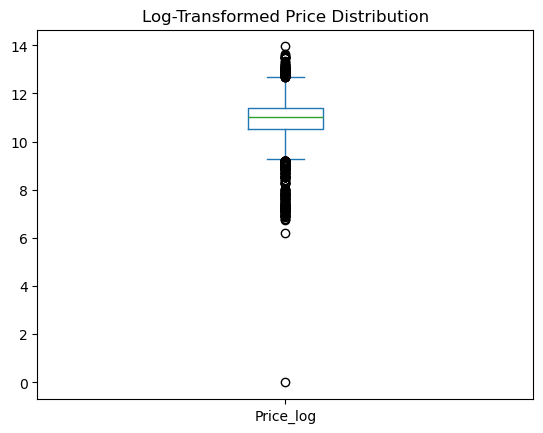

In [27]:
df['Price_log'] = np.log(df['Price'])
df['Price_log'].plot(kind='box', title='Log-Transformed Price Distribution')

In [45]:
df['Category'] = pd.cut(df['Price'],
                       bins=[0,50000,100000,150000,df['Price'].max()],
                        labels=['Budget', 'Mid', 'Premium', 'Luxury'])


In [46]:
df['Category'].value_counts()

Category
Budget     3265
Mid        3113
Premium     921
Luxury      751
Name: count, dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         8051 non-null   object  
 1   Type         8051 non-null   object  
 2   Year         8051 non-null   int64   
 3   Origin       8051 non-null   object  
 4   Color        8051 non-null   object  
 5   Options      8051 non-null   object  
 6   Engine_Size  8051 non-null   float64 
 7   Fuel_Type    8051 non-null   object  
 8   Gear_Type    8051 non-null   object  
 9   Condition    8051 non-null   object  
 10  Mileage      8051 non-null   int64   
 11  Region       8051 non-null   object  
 12  Price        8051 non-null   float64 
 13  Negotiable   8051 non-null   bool    
 14  Car_Age      8051 non-null   int64   
 15  Price_log    8051 non-null   float64 
 16  Category     8050 non-null   category
dtypes: bool(1), category(1), float64(3), int64(3), object(9)
memory usage: 1022.

In [58]:
df['Category'].isna().sum()
df['Category'].dropna(inplace=True) 

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         8051 non-null   object  
 1   Type         8051 non-null   object  
 2   Year         8051 non-null   int64   
 3   Origin       8051 non-null   object  
 4   Color        8051 non-null   object  
 5   Options      8051 non-null   object  
 6   Engine_Size  8051 non-null   float64 
 7   Fuel_Type    8051 non-null   object  
 8   Gear_Type    8051 non-null   object  
 9   Condition    8051 non-null   object  
 10  Mileage      8051 non-null   int64   
 11  Region       8051 non-null   object  
 12  Price        8051 non-null   float64 
 13  Negotiable   8051 non-null   bool    
 14  Car_Age      8051 non-null   int64   
 15  Price_log    8051 non-null   float64 
 16  Category     8050 non-null   category
dtypes: bool(1), category(1), float64(3), int64(3), object(9)
memory usage: 1022.